# Physical layout & pruning: two experiments

Every layout stores the identical 11-column `trips` schema; they differ only in **how rows are grouped
into files** and **ordered inside files**. We isolate the two knobs separately:

**Experiment 1, in-file ordering (partition held = daily).** Each daily `L0` file (one calendar day) is
rewritten with rows sorted three ways + small row-groups (1024):
`L0X` lexicographic, `L0Z` Z-order, `L0H` Hilbert. -> *does the sort method matter?*

**Experiment 2, partitioning x granularity.** Four partitions (hash `L1`, spaceSplit `L2`, MEST `L3`,
time `L4`), each in a **daily** family (file = tile-on-a-day -> file-level skipping) and a **compact**
family (`…s`, file = tile-for-month + in-file sort + small row-groups). -> *which partition, daily vs compact?*

> **Metric notes.** `files_read` is **file-level**: it does not capture row-group skipping *within* a
> file, so in Exp 1 file counts are flat and any effect shows only in runtime. The whole benchmark is run
> at **5 iterations (trimmed mean)**, so the small Exp-1 deltas sit above the run-to-run noise; Exp 2
> changes which *files* are opened, so `files_read` is the right metric there. Both experiments read the
> single benchmark CSV `results/iceberg.csv` (one row per layout x query x window).

In [1]:
# Display-only thesis relabelling (kept identical to evaluation.ipynb for consistency):
# show each benchmark query by its thesis number (Query 4.1..4.10 -> "Q4.1"..) and strip the
# "_daily" storage suffix, applied at plt.show(). Raw data keys / dict keys are untouched.
QLABEL = {
    "both_ports": "Q4.1",
    "harbor_entry": "Q4.2", "harbour_entry": "Q4.2",
    "clip_to_region": "Q4.3",
    "fleet_summary": "Q4.4",
    "bounding_box": "Q4.5",
    "speed_profile": "Q4.6",
    "position_interpolation": "Q4.7",
    "nearest_approach": "Q4.8",
    "collision": "Q4.9",
    "encounter_zone": "Q4.10",
}
def _relabel(s):
    s = s.replace("_daily", "")
    for _name in sorted(QLABEL, key=len, reverse=True):
        s = s.replace(_name, QLABEL[_name])
    return s
import matplotlib.pyplot as _plt_patch
if not getattr(_plt_patch, "_thesis_patched", False):
    _orig_show = _plt_patch.show
    def _thesis_show(*args, **kwargs):
        for _fig in map(_plt_patch.figure, _plt_patch.get_fignums()):
            _st = getattr(_fig, "_suptitle", None)
            if _st is not None:
                _st.set_text(_relabel(_st.get_text()))
            for _ax in _fig.get_axes():
                for _axis in (_ax.xaxis, _ax.yaxis):
                    _tl = _axis.get_ticklabels()
                    if _tl and any(_relabel(_t.get_text()) != _t.get_text() for _t in _tl):
                        _axis.set_ticks(_axis.get_ticklocs())
                        _axis.set_ticklabels(
                            [_relabel(_t.get_text()) for _t in _tl],
                            rotation=_tl[0].get_rotation(), ha=_tl[0].get_ha())
                _ax.set_title(_relabel(_ax.get_title()))
                _leg = _ax.get_legend()
                if _leg:
                    for _t in _leg.get_texts():
                        _t.set_text(_relabel(_t.get_text()))
                for _t in _ax.texts:
                    _t.set_text(_relabel(_t.get_text()))
        return _orig_show(*args, **kwargs)
    _plt_patch.show = _thesis_show
    _plt_patch._thesis_patched = True

import pandas as pd, numpy as np, matplotlib.pyplot as plt

def geomean(s):
    s = pd.Series(s).dropna(); s = s[s > 0]
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

# One iceberg result CSV; `layout` is already the unique key (L2s, L0X, L1_daily, …).
ice = pd.read_csv("results/iceberg.csv")
ice["case"] = ice["query"] + " (" + ice.selectivity + ")"     # one case per query x window
rt = ice.pivot_table(index="case", columns="layout", values="runtime_trimmed_s")
fcount = ice.groupby("layout")["files_total"].first()
print("layouts:", sorted(rt.columns))

layouts: ['L0', 'L0H', 'L0X', 'L0Z', 'L1_daily', 'L1s', 'L2_daily', 'L2s', 'L3_daily', 'L3s', 'L4_daily', 'L4s']


## Experiment 1: in-file ordering on daily `L0` (5-iteration run)

In-file sort on daily L0 — runtime speedup vs L0 (5 iters, trimmed):
   L0X (lexicographic): 1.058x
   L0Z (Z-order      ): 1.059x
   L0H (Hilbert      ): 1.032x
   method spread (max/min): 1.026x

Run-to-run jitter ((median-min)/median): mean 2.2%, p90 4.9%
Pairwise method gaps vs that noise band:
   |L0X-L0Z| = 0.1%
   |L0X-L0H| = 2.5%
   |L0Z-L0H| = 2.6%
=> gaps fall within the noise band: the methods are statistically indistinguishable,
   and in-file sort on daily files yields no measurable speedup (~1x).


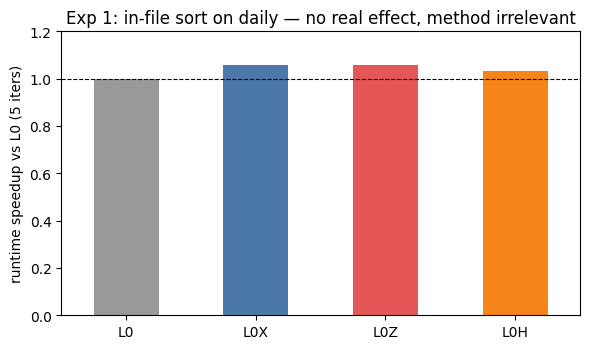

In [2]:
# the in-file-sort layouts from the iters=5 benchmark (file counts are flat; effect shows in runtime).
e1 = pd.read_csv("results/iceberg.csv")
e1 = e1[e1.layout.isin(["L0", "L0X", "L0Z", "L0H"])]
p1 = e1.pivot_table(index=["query","selectivity"], columns="layout", values="runtime_trimmed_s")

methods = {"L0X":"lexicographic","L0Z":"Z-order","L0H":"Hilbert"}
sp = {l: geomean(p1["L0"]/p1[l]) for l in methods}
print("In-file sort on daily L0, runtime speedup vs L0 (5 iters, trimmed):")
for l,nm in methods.items(): print(f"   {l} ({nm:13}): {sp[l]:.3f}x")
print(f"   method spread (max/min): {max(sp.values())/min(sp.values()):.3f}x")

jt = e1[e1.layout.isin(list(methods)+["L0"])]
jit = (jt["runtime_median_s"] - jt["runtime_min_s"]) / jt["runtime_median_s"]
print(f"\nRun-to-run jitter ((median-min)/median): mean {jit.mean()*100:.1f}%, p90 {jit.quantile(.9)*100:.1f}%")
print("Pairwise method gaps vs that noise band:")
for x,y in [("L0X","L0Z"),("L0X","L0H"),("L0Z","L0H")]:
    print(f"   |{x}-{y}| = {abs(geomean(p1[x]/p1[y])-1)*100:.1f}%")
print("=> gaps fall within the noise band: the methods are statistically indistinguishable,")
print("   and in-file sort on daily files yields no measurable speedup (~1x).")

ax = pd.Series({"L0":1.0, **sp}).plot.bar(figsize=(6,3.6), color=["#999","#4c78a8","#e45756","#f58518"])
ax.axhline(1.0,color="k",lw=0.8,ls="--"); ax.set_ylim(0,1.2)
ax.set_ylabel("runtime speedup vs L0 (5 iters)")
ax.set_title("Exp 1: in-file sort on daily, no real effect, method irrelevant")
ax.tick_params(axis="x",rotation=0); plt.tight_layout(); plt.show()

**Takeaway.** On daily files the in-file sort gives **no meaningful speedup**: it lands within run-to-run
noise of 1x, and the *sign isn't even stable across runs* (~1.07x here, ~0.95x in a separate 5-iteration
run), the cleanest sign it's noise. The **three methods are statistically indistinguishable** too (pairwise
gaps <= the noise band). A daily file is only ~7.7k rows -> too few row-groups for in-file ordering to skip.
Two consequences:

- The sorted-compact family's **lexicographic** in-file sort is justified by **simplicity**, not a
  benchmark win, Exp 1 shows the method is irrelevant (cheapest to compute among equals).
- In-file ordering only pays off when files are **big enough to have many row-groups**, i.e. on
  **month-compact tiles**, not daily files. That is exactly the setting of Experiment 2.

And structurally: a daily file covers all of Denmark, so a spatial query still opens every day-file in the
window, in-file ordering can never skip whole files. -> partitioning is needed (Exp 2).

## Experiment 2: partitioning x granularity

Runtime speedup vs L0 (geomean):     daily      compact
  hash (L1)                 1.10x      0.62x
  space·spaceSplit (L2)     2.99x      4.21x
  space·MEST (L3)           3.05x      4.57x
  time (L4)                 2.27x      2.16x

File count (files_total):            daily   compact   reduction
  hash (L1)                  496      16    31.0x fewer
  space·spaceSplit (L2)     4154     302    13.8x fewer
  space·MEST (L3)           4133     299    13.8x fewer
  time (L4)                  744      24    31.0x fewer


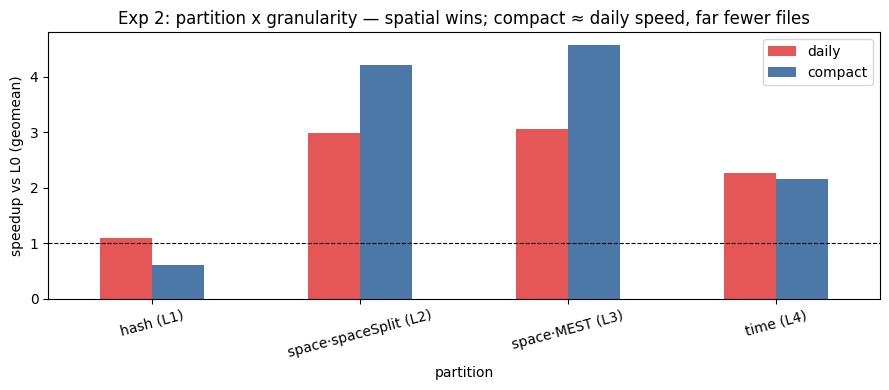

In [3]:
daily = {"hash (L1)":"L1_daily","space,spaceSplit (L2)":"L2_daily","space,MEST (L3)":"L3_daily","time (L4)":"L4_daily"}
comp  = {"hash (L1)":"L1s","space,spaceSplit (L2)":"L2s","space,MEST (L3)":"L3s","time (L4)":"L4s"}

print("Runtime speedup vs L0 (geomean):     daily      compact")
rows=[]
for k in daily:
    d = geomean(rt["L0"]/rt[daily[k]]); c = geomean(rt["L0"]/rt[comp[k]])
    print(f"  {k:24} {d:5.2f}x     {c:5.2f}x"); rows.append({"partition":k,"daily":d,"compact":c})
print("\nFile count (files_total):            daily   compact   reduction")
for k in daily:
    fd, fc = fcount.get(daily[k]), fcount.get(comp[k])
    print(f"  {k:24} {fd:5.0f}   {fc:5.0f}    {fd/fc:.1f}x fewer")

sp2 = pd.DataFrame(rows).set_index("partition")
ax = sp2.plot.bar(figsize=(9,4), color=["#e45756","#4c78a8"])
ax.axhline(1.0,color="k",lw=0.8,ls="--"); ax.set_ylabel("speedup vs L0 (geomean)")
ax.set_title("Exp 2: partition x granularity, spatial wins; compact ~ daily speed, far fewer files")
ax.tick_params(axis="x",rotation=15); plt.tight_layout(); plt.show()